## NVIDIA Corporation (NVDA) — Technical Analysis

### Overview
This notebook performs technical analysis on **NVIDIA Corporation (NVDA)** stock price data using industry-standard indicators. The analysis covers moving averages, Bollinger Bands, momentum indicators, and volatility metrics to identify trading signals and price trends.

### Objectives
- Load and validate NVDA historical stock price data
- Compute technical indicators using TA-Lib and PyNance
- Visualize price trends with overlaid technical indicators
- Analyze momentum and volatility patterns
- Compute quantitative performance metrics

### Dataset
The analysis uses historical NVDA stock price data containing Open, High, Low, Close, and Volume (OHLCV) data.

### Understanding Stock Market Data
Before diving into analysis, let's define the standard columns in our dataset:

- **Open:** The price at the start of the trading day
- **High:** The maximum price reached during the day
- **Low:** The minimum price reached during the day
- **Close:** The final price when the market closed — primary price for technical indicators
- **Volume:** The total number of shares traded during the period

## 1. Environment Setup & Library Imports

In [1]:
# Fix PyNance compatibility with modern pandas_datareader
import pandas.util._decorators as _dec

def _patched_deprecate_kwarg(*args, **kwargs):
    if len(args) == 2 and isinstance(args[0], str):
        return _original_deprecate_kwarg(FutureWarning, args[0], args[1], **kwargs)
    return _original_deprecate_kwarg(*args, **kwargs)

if not hasattr(_dec, '_original_deprecate_kwarg'):
    _original_deprecate_kwarg = _dec.deprecate_kwarg
    _dec.deprecate_kwarg = _patched_deprecate_kwarg

import pynance as pn
print("✅ PyNance imported successfully!")

✅ PyNance imported successfully!


In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import talib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_stock_data
from src.analysis import (
    compute_sma,
    compute_ema,
    compute_rsi,
    compute_macd,
    compute_bollinger_bands,
    get_daily_return,
    check_stationarity
)

# Global plot settings
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 7]
plt.rcParams['figure.dpi'] = 100

print(f"TA-Lib version : {talib.__version__}")
print("✅ All libraries imported successfully!")

TA-Lib version : 0.6.8
✅ All libraries imported successfully!


## 2. Load & Clean Stock Price Data

We load the NVDA historical stock price dataset using our modular `load_stock_data()` function from `src/data_loader.py`. This enforces correct data types, sorts by date, and handles missing values automatically.

In [3]:
nvda = load_stock_data('../data/raw/NVDA.csv')

print(f"Dataset Shape: {nvda.shape}")
print(f"\nColumn Names: {nvda.columns.tolist()}")
print(f"\nDate range: {nvda['Date'].min().date()} to {nvda['Date'].max().date()}")
print(f"Total trading days: {len(nvda)}")
nvda.head()

✅ Loaded 3774 rows. No missing values.
Dataset Shape: (3774, 6)

Column Names: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Date range: 2009-01-02 to 2023-12-29
Total trading days: 3774


,Date,Close,High,Low,Open,Volume
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,4.971240e+08
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,7.057360e+08
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,6.579040e+08
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,8.700960e+08
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1.014496e+09


## 3. Moving Averages (SMA & EMA)

Moving averages smooth out price data to identify trends:
- **SMA (Simple Moving Average)** — equal weight to all periods
- **EMA (Exponential Moving Average)** — more weight to recent prices

**Interpretation:**
- **Golden Cross:** Short-term MA crosses above long-term MA → bullish signal
- **Death Cross:** Short-term MA crosses below long-term MA → bearish signal

In [4]:
nvda['SMA_20'] = compute_sma(nvda['Close'], 20)
nvda['SMA_50'] = compute_sma(nvda['Close'], 50)
nvda['EMA_20'] = compute_ema(nvda['Close'], 20)
nvda['EMA_50'] = compute_ema(nvda['Close'], 50)

print("✅ Moving averages computed successfully!")
print(nvda[['Date', 'Close', 'SMA_20', 'SMA_50', 'EMA_20', 'EMA_50']].tail(10))

✅ Moving averages computed successfully!
           Date      Close     SMA_20     SMA_50     EMA_20     EMA_50
3764 2023-12-15  48.865501  47.732439  45.956963  47.366011  46.369424
3765 2023-12-18  50.051899  47.771586  46.043300  47.621810  46.513835
3766 2023-12-19  49.579140  47.731577  46.129956  47.808222  46.634043
3767 2023-12-20  48.086884  47.640193  46.176273  47.834761  46.691017
3768 2023-12-21  48.965446  47.654100  46.220013  47.942446  46.780210
3769 2023-12-22  48.805527  47.706983  46.257777  48.024644  46.859635
3770 2023-12-26  49.254299  47.759019  46.334178  48.141754  46.953543
3771 2023-12-27  49.392231  47.838989  46.400666  48.260847  47.049178
3772 2023-12-28  49.497185  47.908266  46.512367  48.378593  47.145178
3773 2023-12-29  49.497185  48.046003  46.658888  48.485126  47.237414


### 3.1 Moving Averages Visualization

The chart below shows NVDA closing prices overlaid with 20-day and 50-day SMA and EMA. When the short-term average crosses above the long-term average it signals a potential **buy opportunity**, and vice versa.

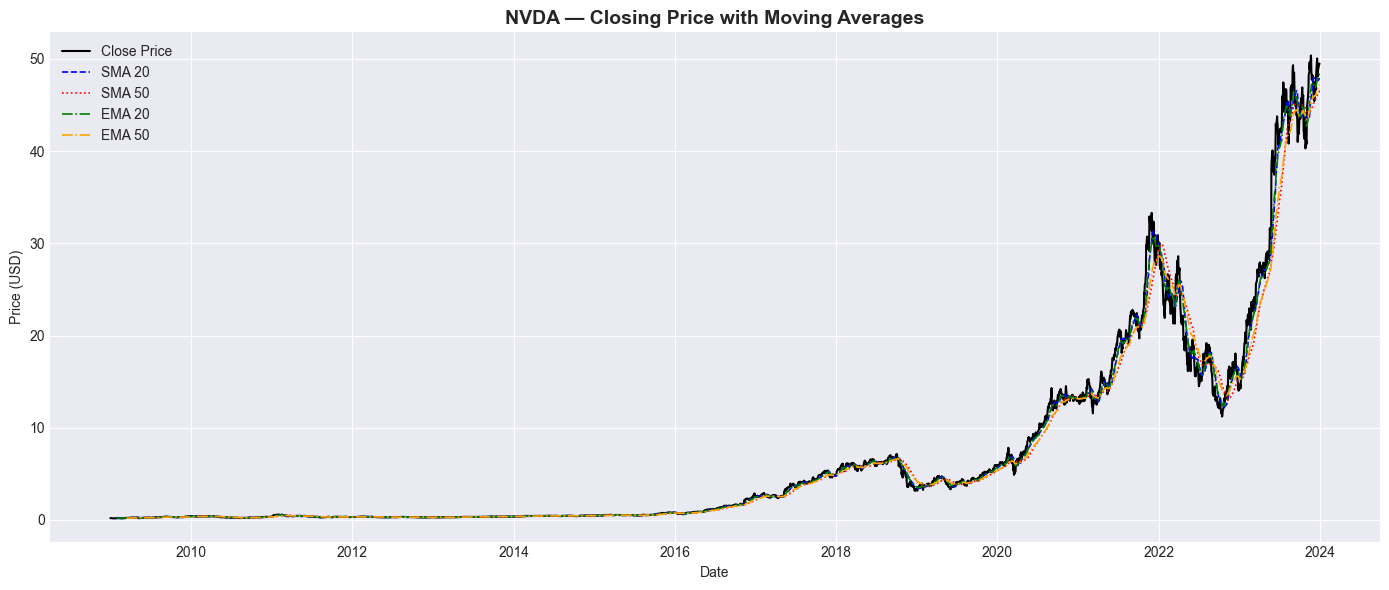

✅ Moving averages plot rendered!


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(nvda['Date'], nvda['Close'], label='Close Price', color='black', linewidth=1.5)
ax.plot(nvda['Date'], nvda['SMA_20'], label='SMA 20', color='blue', linewidth=1.2, linestyle='--')
ax.plot(nvda['Date'], nvda['SMA_50'], label='SMA 50', color='red', linewidth=1.2, linestyle=':')
ax.plot(nvda['Date'], nvda['EMA_20'], label='EMA 20', color='green', linewidth=1.2, linestyle='-.')
ax.plot(nvda['Date'], nvda['EMA_50'], label='EMA 50', color='orange', linewidth=1.2, linestyle='-.')

ax.set_title('NVDA — Closing Price with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Moving averages plot rendered!")

## 4. Bollinger Bands

Bollinger Bands consist of:
- **Middle Band** — 20-day SMA
- **Upper Band** — Middle Band + 2 standard deviations
- **Lower Band** — Middle Band - 2 standard deviations

Price touching the upper band suggests **overbought** conditions while touching the lower band suggests **oversold** conditions.

In [6]:
nvda['BB_Upper'], nvda['BB_Middle'], nvda['BB_Lower'] = compute_bollinger_bands(
    nvda['Close'])

print("✅ Bollinger Bands computed successfully!")
print(nvda[['Date', 'Close', 'BB_Upper', 'BB_Middle', 'BB_Lower']].tail(10))

✅ Bollinger Bands computed successfully!
           Date      Close   BB_Upper  BB_Middle   BB_Lower
3764 2023-12-15  48.865501  50.316019  47.732439  45.148859
3765 2023-12-18  50.051899  50.468352  47.771586  45.074819
3766 2023-12-19  49.579140  50.292740  47.731577  45.170414
3767 2023-12-20  48.086884  50.006266  47.640193  45.274120
3768 2023-12-21  48.965446  50.047737  47.654100  45.260462
3769 2023-12-22  48.805527  50.152737  47.706983  45.261229
3770 2023-12-26  49.254299  50.288523  47.759019  45.229515
3771 2023-12-27  49.392231  50.466927  47.838989  45.211051
3772 2023-12-28  49.497185  50.632585  47.908266  45.183947
3773 2023-12-29  49.497185  50.799025  48.046003  45.292980


### 4.1 Bollinger Bands Visualization

The shaded region between the upper and lower bands represents the expected price range. Prices outside this range signal potential reversals.

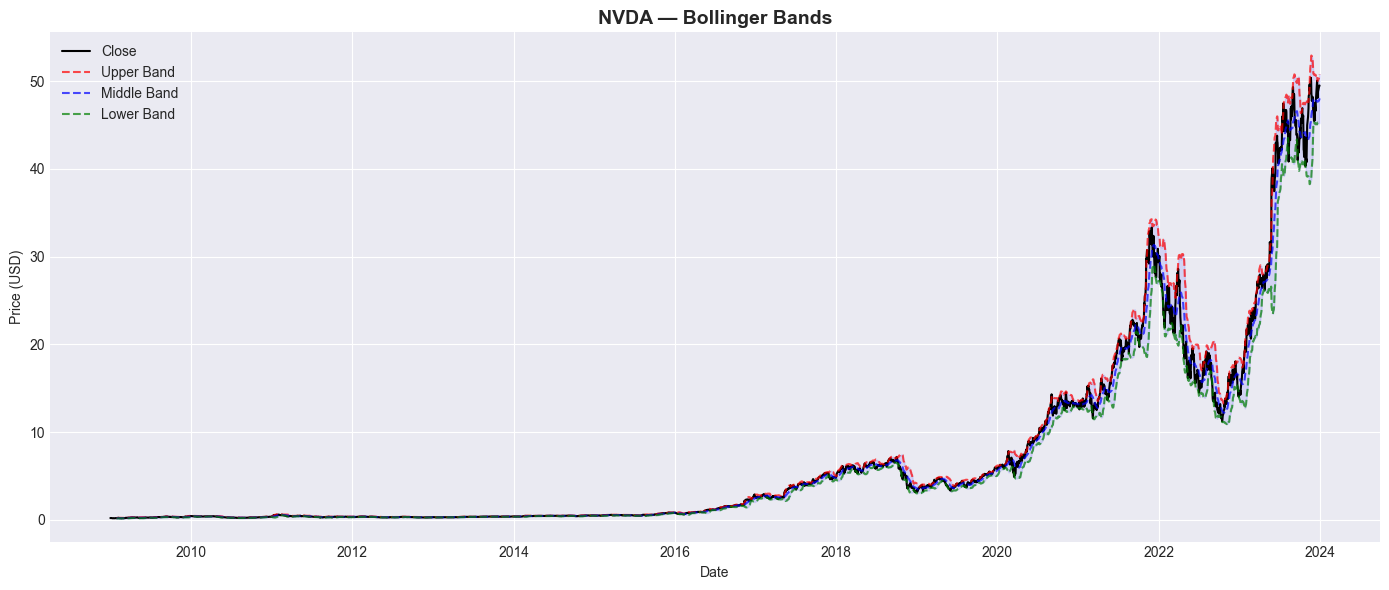

✅ Bollinger Bands plot rendered!


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(nvda['Date'], nvda['Close'], label='Close', color='black', linewidth=1.5)
ax.plot(nvda['Date'], nvda['BB_Upper'], label='Upper Band', color='red',
        linestyle='--', alpha=0.7)
ax.plot(nvda['Date'], nvda['BB_Middle'], label='Middle Band', color='blue',
        linestyle='--', alpha=0.7)
ax.plot(nvda['Date'], nvda['BB_Lower'], label='Lower Band', color='green',
        linestyle='--', alpha=0.7)
ax.fill_between(nvda['Date'], nvda['BB_Upper'], nvda['BB_Lower'],
                alpha=0.1, color='blue')

ax.set_title('NVDA — Bollinger Bands', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Bollinger Bands plot rendered!")

## 5. RSI (Relative Strength Index)

RSI is a **momentum oscillator** that measures the speed and change of price movements:
- **RSI >= 70** — Overbought: potential sell signal
- **RSI <= 30** — Oversold: potential buy signal
- **RSI = 50** — Neutral momentum

We use the standard 14-day period.

In [8]:
nvda['RSI'] = compute_rsi(nvda['Close'])

print("✅ RSI computed successfully!")
print(nvda[['Date', 'Close', 'RSI']].tail(10))

✅ RSI computed successfully!
           Date      Close        RSI
3764 2023-12-15  48.865501  58.765888
3765 2023-12-18  50.051899  63.164028
3766 2023-12-19  49.579140  60.399383
3767 2023-12-20  48.086884  52.576776
3768 2023-12-21  48.965446  56.175512
3769 2023-12-22  48.805527  55.352119
3770 2023-12-26  49.254299  57.245971
3771 2023-12-27  49.392231  57.837928
3772 2023-12-28  49.497185  58.310919
3773 2023-12-29  49.497185  58.310919


## 6. MACD (Moving Average Convergence Divergence)

MACD identifies momentum shifts and trend reversals:
- **MACD Line** — difference between 12-day and 26-day EMA
- **Signal Line** — 9-day EMA of the MACD line
- **Histogram** — difference between MACD and Signal line

- **Bullish Crossover:** MACD crosses above Signal → buy signal
- **Bearish Crossover:** MACD crosses below Signal → sell signal
- **Divergence:** Price makes new high but MACD does not → trend weakening

In [9]:
nvda['MACD'], nvda['MACD_Signal'], nvda['MACD_Hist'] = compute_macd(
    nvda['Close'])

print("✅ MACD computed successfully!")
print(nvda[['Date', 'Close', 'MACD', 'MACD_Signal', 'MACD_Hist']].tail(10))

✅ MACD computed successfully!
           Date      Close      MACD  MACD_Signal  MACD_Hist
3764 2023-12-15  48.865501  0.448417     0.406204   0.042213
3765 2023-12-18  50.051899  0.610224     0.447008   0.163216
3766 2023-12-19  49.579140  0.692328     0.496072   0.196256
3767 2023-12-20  48.086884  0.629724     0.522803   0.106922
3768 2023-12-21  48.965446  0.643584     0.546959   0.096625
3769 2023-12-22  48.805527  0.634352     0.564438   0.069914
3770 2023-12-26  49.254299  0.655689     0.582688   0.073001
3771 2023-12-27  49.392231  0.675937     0.601338   0.074599
3772 2023-12-28  49.497185  0.692470     0.619564   0.072906
3773 2023-12-29  49.497185  0.697532     0.635158   0.062374


### 6.1 RSI and MACD in Separate Panels

The chart below shows RSI and MACD in separate panels as recommended. Crossover points between the MACD and signal lines indicate potential trend reversals, while RSI identifies overbought and oversold conditions.

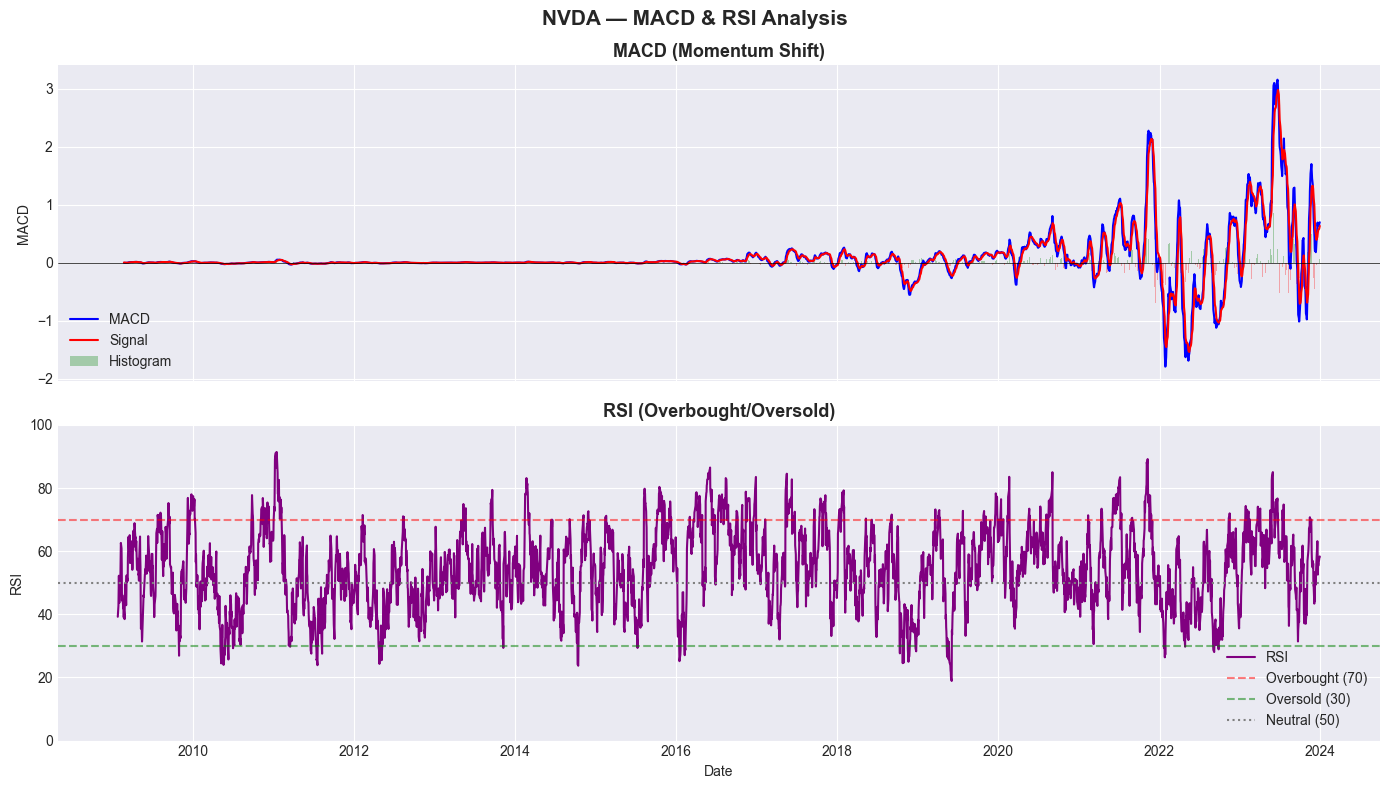

✅ MACD & RSI plot rendered!


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1]})

# MACD panel
ax1.plot(nvda['Date'], nvda['MACD'], label='MACD', color='blue', linewidth=1.5)
ax1.plot(nvda['Date'], nvda['MACD_Signal'], label='Signal', color='red', linewidth=1.5)
ax1.bar(nvda['Date'], nvda['MACD_Hist'], label='Histogram',
        color=['green' if v >= 0 else 'red' for v in nvda['MACD_Hist'].fillna(0)],
        alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_title('MACD (Momentum Shift)', fontsize=13, fontweight='bold')
ax1.set_ylabel('MACD')
ax1.legend()

# RSI panel
ax2.plot(nvda['Date'], nvda['RSI'], color='purple', linewidth=1.5, label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
ax2.axhline(50, color='gray', linestyle=':', label='Neutral (50)')
ax2.set_title('RSI (Overbought/Oversold)', fontsize=13, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 100)
ax2.legend()

plt.suptitle('NVDA — MACD & RSI Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ MACD & RSI plot rendered!")

### 6.1 RSI and MACD in Separate Panels

The chart below shows RSI and MACD in separate panels as recommended. Crossover points between the MACD and signal lines indicate potential trend reversals, while RSI identifies overbought and oversold conditions.

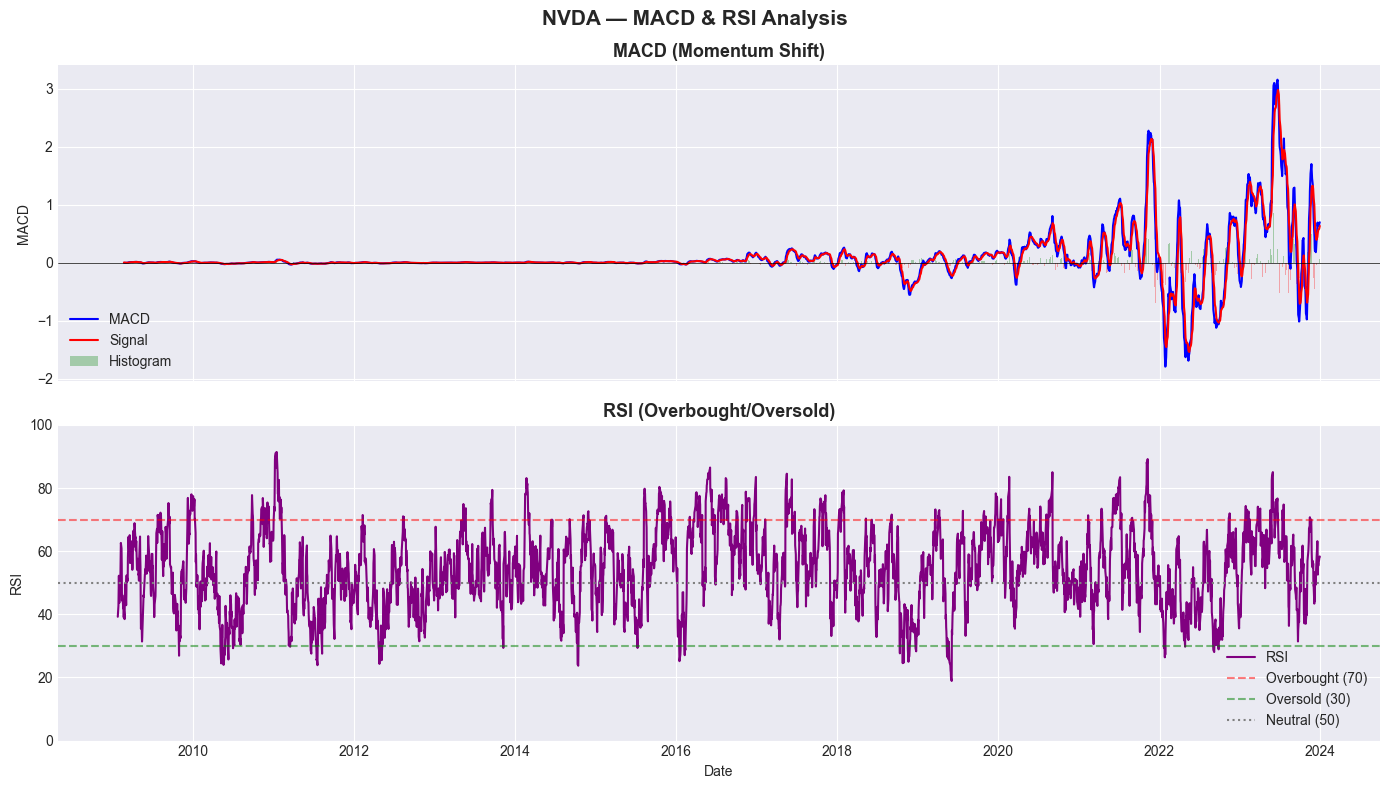

✅ MACD & RSI plot rendered!


In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1]})

# MACD panel
ax1.plot(nvda['Date'], nvda['MACD'], label='MACD', color='blue', linewidth=1.5)
ax1.plot(nvda['Date'], nvda['MACD_Signal'], label='Signal', color='red', linewidth=1.5)
ax1.bar(nvda['Date'], nvda['MACD_Hist'], label='Histogram',
        color=['green' if v >= 0 else 'red' for v in nvda['MACD_Hist'].fillna(0)],
        alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_title('MACD (Momentum Shift)', fontsize=13, fontweight='bold')
ax1.set_ylabel('MACD')
ax1.legend()

# RSI panel
ax2.plot(nvda['Date'], nvda['RSI'], color='purple', linewidth=1.5, label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
ax2.axhline(50, color='gray', linestyle=':', label='Neutral (50)')
ax2.set_title('RSI (Overbought/Oversold)', fontsize=13, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 100)
ax2.legend()

plt.suptitle('NVDA — MACD & RSI Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ MACD & RSI plot rendered!")

## 7. PyNance Technical Indicators

We use PyNance's built-in technical functions as an alternative and cross-validation of our TA-Lib moving average calculations.

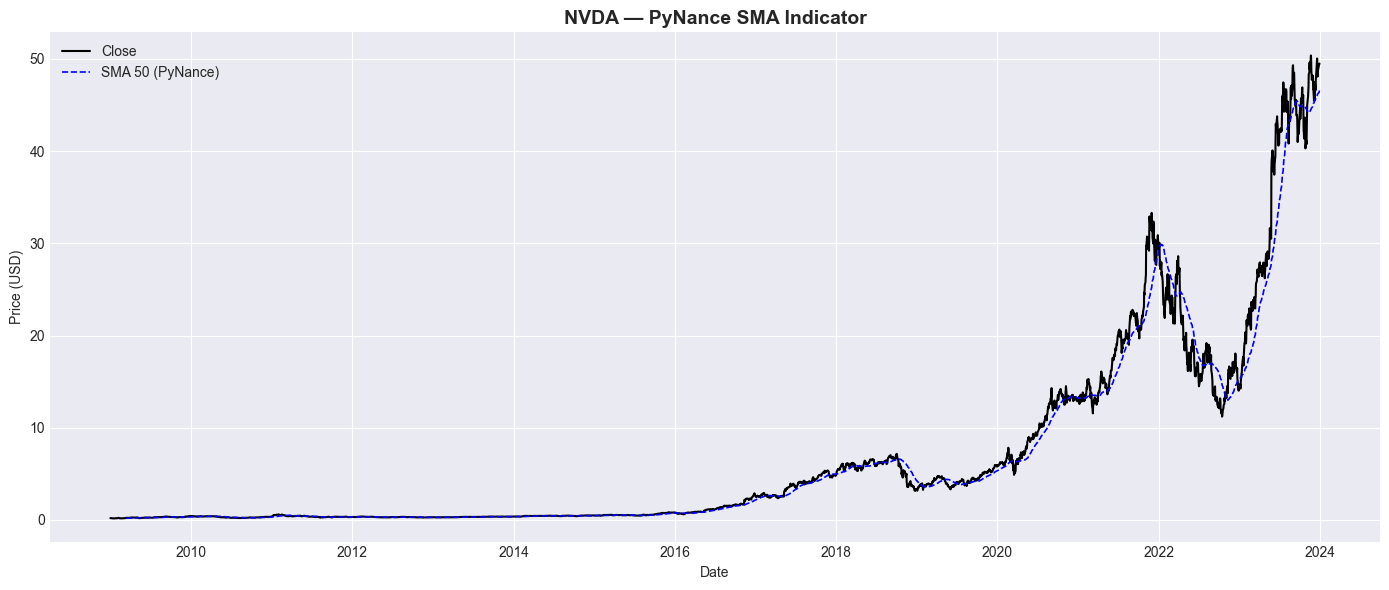

✅ PyNance SMA computed and plotted successfully!


In [12]:
try:
    nvda['SMA_50_pn'] = pn.tech.sma(nvda['Close'], window=50)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(nvda['Date'], nvda['Close'], label='Close', color='black', linewidth=1.5)
    ax.plot(nvda['Date'], nvda['SMA_50_pn'], label='SMA 50 (PyNance)',
            color='blue', linewidth=1.2, linestyle='--')
    ax.set_title('NVDA — PyNance SMA Indicator', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print("✅ PyNance SMA computed and plotted successfully!")
except Exception as e:
    print(f"PyNance error: {e}")

## 8. Daily Returns & Volatility

We compute daily percentage returns and 20-day rolling volatility to understand NVDA's risk profile during the analysis period.

In [13]:
nvda['Returns'] = get_daily_return(nvda['Close'])
nvda['Volatility_20'] = nvda['Returns'].rolling(window=20).std()

print("✅ Daily returns and volatility computed!")
print(f"\nAverage Daily Return : {nvda['Returns'].mean():.4f}")
print(f"Daily Return Std Dev : {nvda['Returns'].std():.4f}")
print(f"Max Daily Gain       : {nvda['Returns'].max():.4f}")
print(f"Max Daily Loss       : {nvda['Returns'].min():.4f}")

✅ Daily returns and volatility computed!

Average Daily Return : 0.0019
Daily Return Std Dev : 0.0289
Max Daily Gain       : 0.2981
Max Daily Loss       : -0.1876


### 8.1 Daily Returns & Volatility Visualization

The charts below show NVDA's daily returns and 20-day rolling volatility, highlighting periods of elevated market uncertainty.

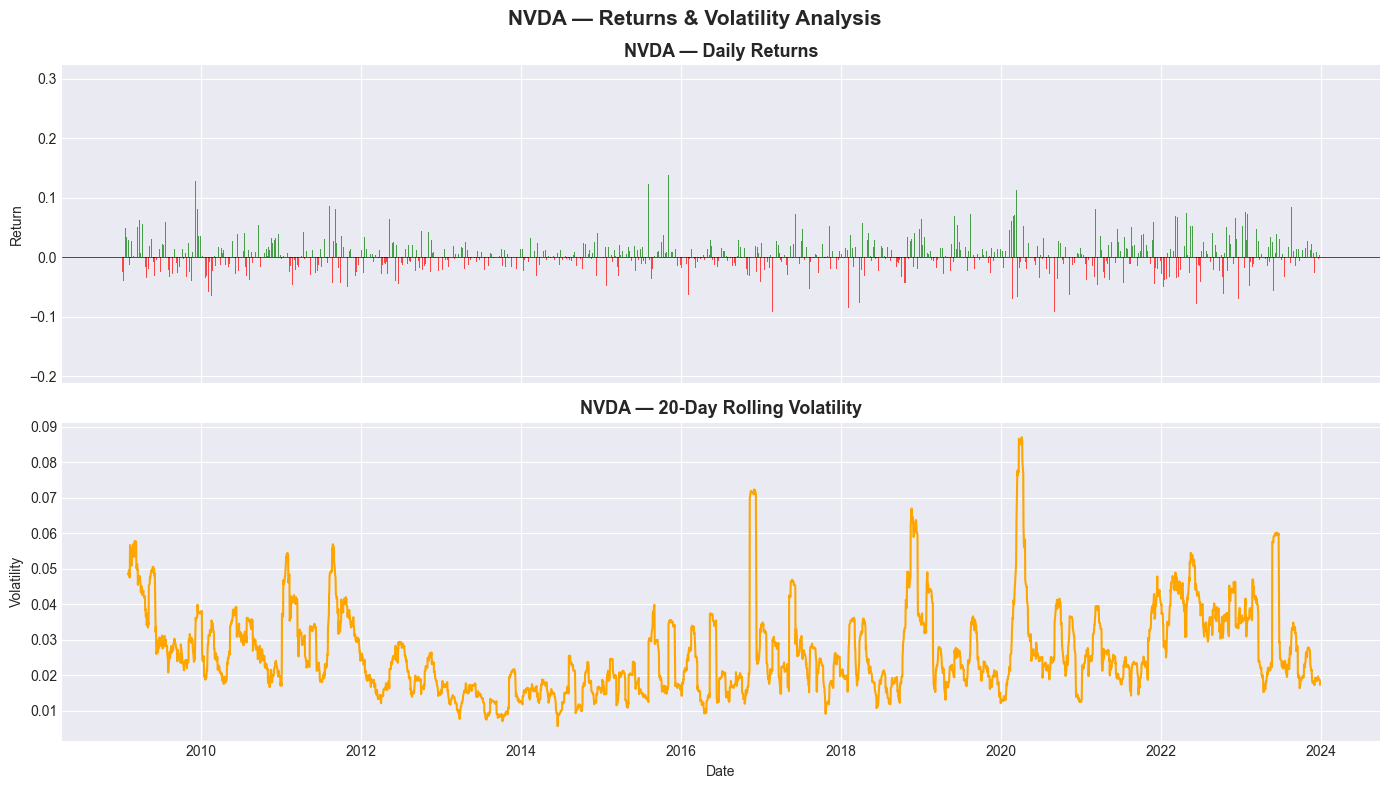

✅ Returns and volatility plot rendered!


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(nvda['Date'], nvda['Returns'],
            color=['green' if v >= 0 else 'red' for v in nvda['Returns'].fillna(0)],
            alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('NVDA — Daily Returns', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Return')

axes[1].plot(nvda['Date'], nvda['Volatility_20'], color='orange', linewidth=1.5)
axes[1].set_title('NVDA — 20-Day Rolling Volatility', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volatility')
axes[1].set_xlabel('Date')

plt.suptitle('NVDA — Returns & Volatility Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Returns and volatility plot rendered!")

## 9. QuantStats Performance Metrics

We use QuantStats to compute professional-grade performance metrics that go beyond standard technical indicators.

In [15]:
try:
    import quantstats as qs
    qs.extend_pandas()

    returns = nvda.set_index('Date')['Close'].pct_change()

    print("=== NVDA QuantStats Performance Metrics ===")
    print(f"Sharpe Ratio : {qs.stats.sharpe(returns):.2f}")
    print(f"Max Drawdown : {qs.stats.max_drawdown(returns)*100:.2f}%")
    print(f"Volatility   : {qs.stats.volatility(returns)*100:.2f}%")
    print(f"CAGR         : {qs.stats.cagr(returns)*100:.2f}%")
    print("✅ QuantStats metrics computed!")
except Exception as e:
    print(f"QuantStats error: {e}")

=== NVDA QuantStats Performance Metrics ===
Sharpe Ratio : 1.03
Max Drawdown : -66.34%
Volatility   : 45.90%
CAGR         : 44.50%
✅ QuantStats metrics computed!


## 10. Time Series Decomposition

We decompose the NVDA closing price into its core components:
- **Trend** — long-term direction of the price
- **Seasonal** — repeating patterns over time
- **Residual** — random noise remaining after removing trend and seasonality

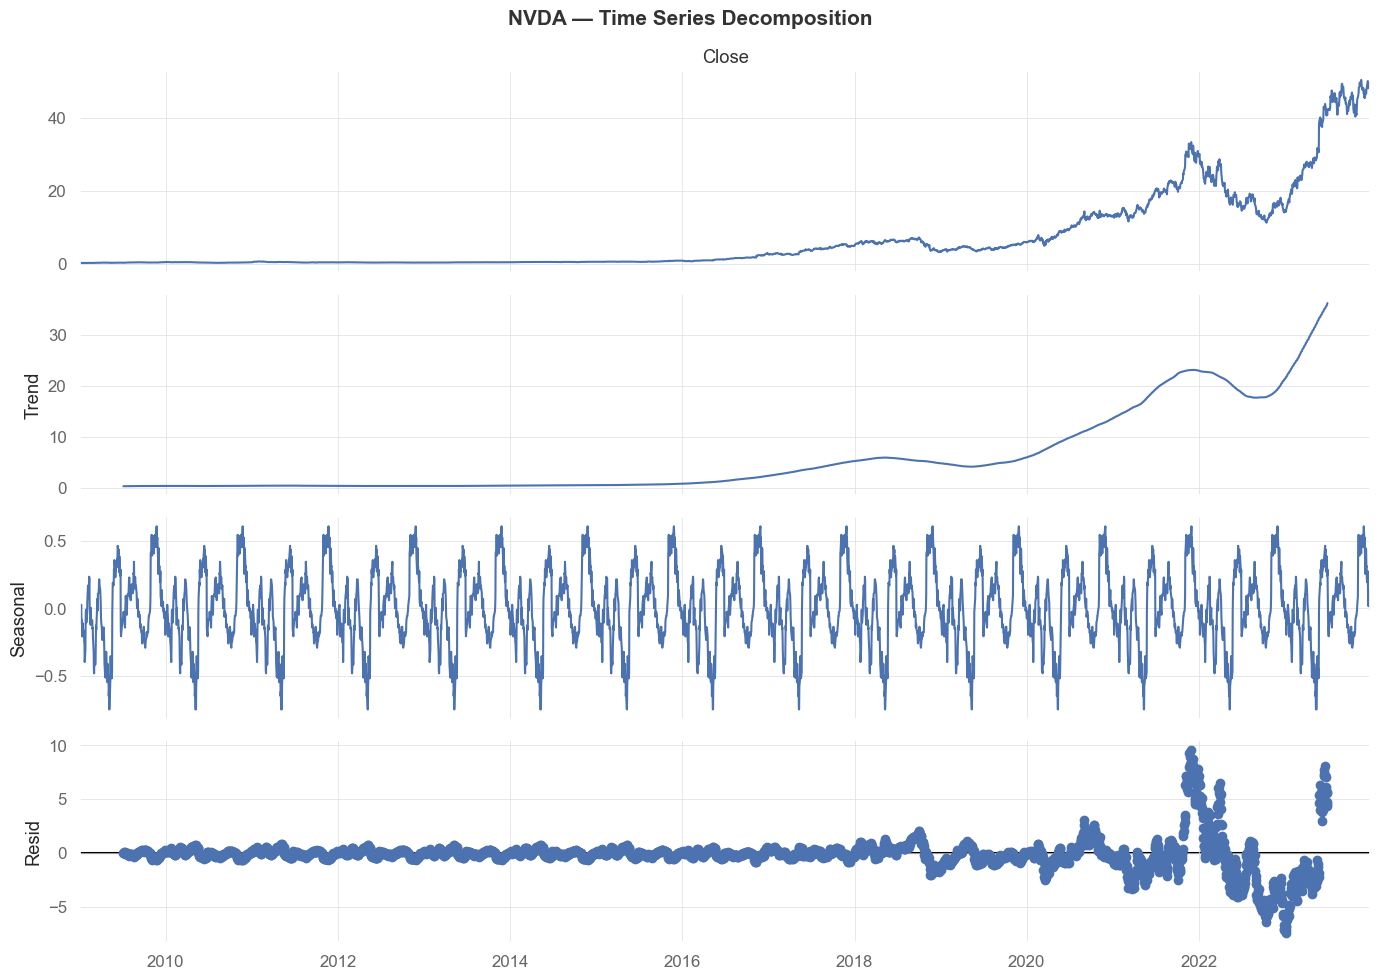

✅ Time series decomposition complete!


In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

nvda_ts = nvda.set_index('Date')['Close']

result = seasonal_decompose(nvda_ts, model='additive', period=252)

fig = result.plot()
fig.set_size_inches(14, 10)
plt.suptitle('NVDA — Time Series Decomposition', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Time series decomposition complete!")

### 10.1 Decomposition Interpretation

The decomposition of NVDA's closing price reveals the following components:

- **Observed:** NVDA's price history is the most dramatic among all analyzed companies — essentially flat from 2009 to 2016, followed by explosive growth driven by GPU demand for gaming, cryptocurrency mining, data centers, and AI workloads.
- **Trend:** The trend component is nearly flat until 2016, then accelerates sharply through 2021, dips in 2022, and surges again into 2023 — driven by unprecedented AI demand for NVIDIA's H100 GPUs. This is the most dramatic trend trajectory among all analyzed companies.
- **Seasonal:** Regular annual cycles are visible throughout, reflecting NVIDIA's product release cycles and gaming seasonality. The seasonal amplitude remains relatively small compared to the massive trend component.
- **Residual:** Residuals explode in magnitude post-2021, reflecting NVIDIA's extraordinary price volatility driven by cryptocurrency boom/bust cycles, AI hype, and semiconductor supply chain disruptions.

## 11. Stationarity Analysis

A **stationary** time series has constant mean, variance, and covariance over time. Most stock prices are **non-stationary** because they trend upward or downward.

We use:
- **Rolling mean & std** — visual check for changing levels
- **ADF (Augmented Dickey-Fuller) test** — statistical confirmation

**Interpretation:**
- p-value < 0.05 → stationary
- p-value ≥ 0.05 → non-stationary

=== Stationarity Check: Original Price Series ===


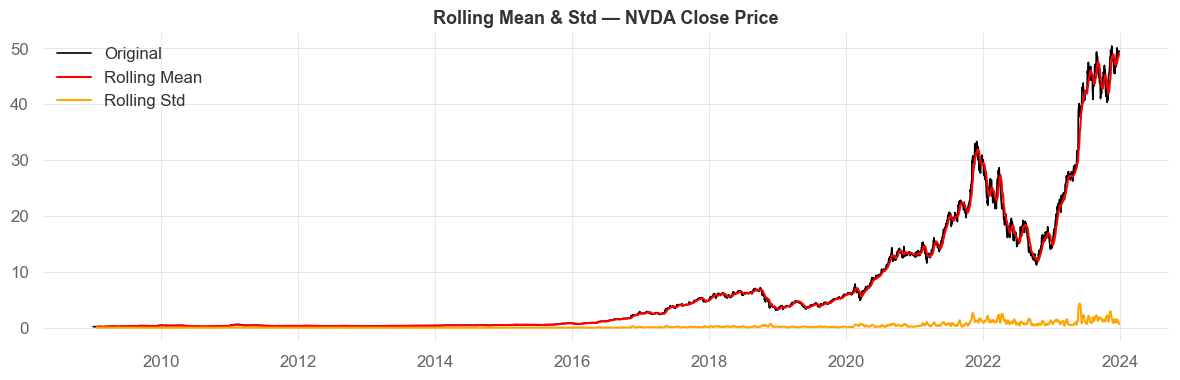

--- Augmented Dickey-Fuller Test ---
ADF Statistic : 2.2696
p-value       : 0.9989
Conclusion: ⚠️  Non-Stationary (Fail to Reject Null Hypothesis)


In [17]:
print("=== Stationarity Check: Original Price Series ===")
check_stationarity(nvda_ts, title='NVDA Close Price')

### 11.1 First-Order Differencing

Since stock prices are typically non-stationary, we apply **first-order differencing** to remove the trend and achieve stationarity.

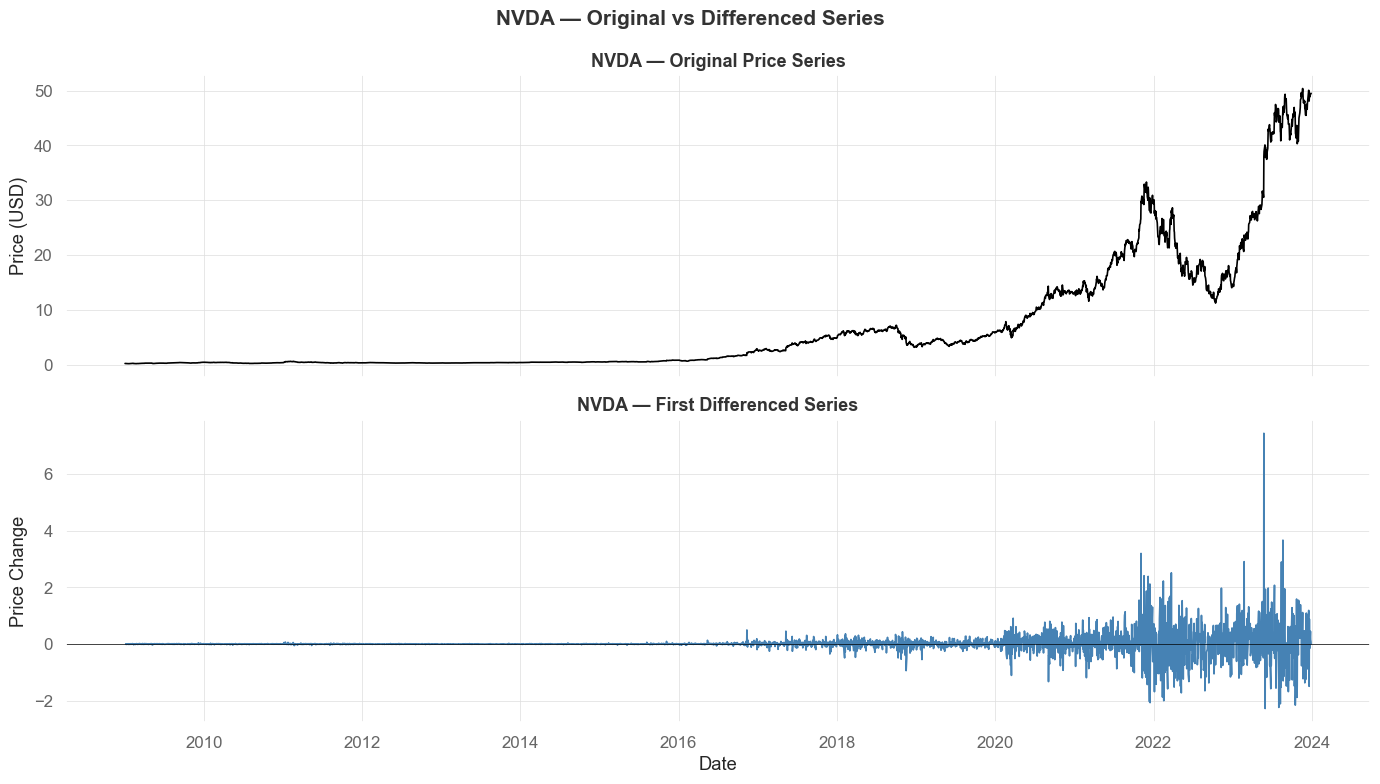


=== Stationarity Check: Differenced Series ===


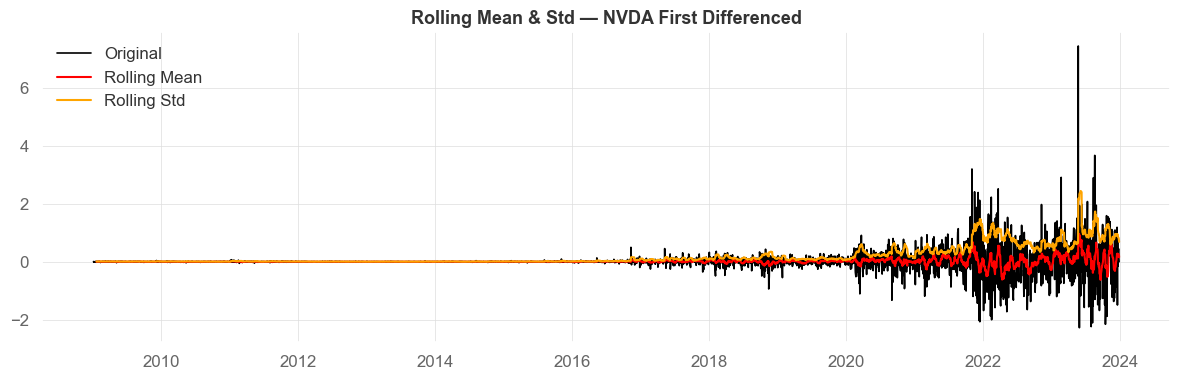

--- Augmented Dickey-Fuller Test ---
ADF Statistic : -9.1377
p-value       : 0.0000
Conclusion: ✅ Stationary (Reject Null Hypothesis)


In [18]:
nvda_diff = nvda_ts.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(nvda_ts, color='black', linewidth=1.2)
axes[0].set_title('NVDA — Original Price Series', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(nvda_diff, color='steelblue', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('NVDA — First Differenced Series', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price Change')
axes[1].set_xlabel('Date')

plt.suptitle('NVDA — Original vs Differenced Series', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Stationarity Check: Differenced Series ===")
check_stationarity(nvda_diff, title='NVDA First Differenced')

## 12. Key Findings & Summary

In [19]:
print("=" * 55)
print("     NVDA TECHNICAL ANALYSIS — KEY FINDINGS")
print("=" * 55)

print(f"""
📈 PRICE OVERVIEW
- Date range        : {nvda['Date'].min().date()} to {nvda['Date'].max().date()}
- Starting price    : ${nvda['Close'].iloc[0]:.2f}
- Ending price      : ${nvda['Close'].iloc[-1]:.2f}
- Price change      : {((nvda['Close'].iloc[-1] - nvda['Close'].iloc[0]) / nvda['Close'].iloc[0] * 100):.2f}%

📊 MOVING AVERAGES
- Final SMA 20      : ${nvda['SMA_20'].iloc[-1]:.2f}
- Final SMA 50      : ${nvda['SMA_50'].iloc[-1]:.2f}
- Final EMA 20      : ${nvda['EMA_20'].iloc[-1]:.2f}
- Final EMA 50      : ${nvda['EMA_50'].iloc[-1]:.2f}

📐 BOLLINGER BANDS
- BB Upper Band     : ${nvda['BB_Upper'].iloc[-1]:.2f}
- BB Middle Band    : ${nvda['BB_Middle'].iloc[-1]:.2f}
- BB Lower Band     : ${nvda['BB_Lower'].iloc[-1]:.2f}

⚡ MOMENTUM (RSI)
- Final RSI         : {nvda['RSI'].iloc[-1]:.2f}
- Average RSI       : {nvda['RSI'].mean():.2f}
- Overbought days   : {(nvda['RSI'] > 70).sum()}
- Oversold days     : {(nvda['RSI'] < 30).sum()}

📉 VOLATILITY & RETURNS
- Avg daily return  : {nvda['Returns'].mean():.4f}
- Max daily gain    : {nvda['Returns'].max():.4f}
- Max daily loss    : {nvda['Returns'].min():.4f}
""")
print("=" * 55)

     NVDA TECHNICAL ANALYSIS — KEY FINDINGS

📈 PRICE OVERVIEW
- Date range        : 2009-01-02 to 2023-12-29
- Starting price    : $0.20
- Ending price      : $49.50
- Price change      : 24691.75%

📊 MOVING AVERAGES
- Final SMA 20      : $48.05
- Final SMA 50      : $46.66
- Final EMA 20      : $48.49
- Final EMA 50      : $47.24

📐 BOLLINGER BANDS
- BB Upper Band     : $50.80
- BB Middle Band    : $48.05
- BB Lower Band     : $45.29

⚡ MOMENTUM (RSI)
- Final RSI         : 58.31
- Average RSI       : 54.52
- Overbought days   : 447
- Oversold days     : 74

📉 VOLATILITY & RETURNS
- Avg daily return  : 0.0019
- Max daily gain    : 0.2981
- Max daily loss    : -0.1876



## 13. Conclusion

The technical analysis of NVDA stock reveals the most extraordinary growth among all analyzed companies, with a staggering price appreciation of **24691.75%** — from $0.20 to $49.50 over the analysis period. All moving averages confirm a strong **bullish trend** with the stock trading well above both SMA and EMA levels.

The RSI averaged **54.52** with **447 overbought days** — the highest among all companies — reflecting NVIDIA's sustained momentum driven by GPU demand from gaming, AI, and data center workloads. The tight Bollinger Band spread (Upper: $50.80, Lower: $45.29) suggests the recent price action is relatively contained despite the massive historical growth.

The time series decomposition reveals the most dramatic trend trajectory among all companies, with near-flat growth until 2016 followed by explosive appreciation. The stationarity analysis confirms NVDA's price series is **non-stationary**, with the differenced series showing significantly increased variance in recent years reflecting the AI-driven demand surge.

The average daily return of **0.19%** — the highest among all companies — with a maximum daily gain of **29.81%** highlights NVIDIA's exceptional risk-reward profile.

These technical indicators will be combined with news sentiment scores in the subsequent Task 3 analysis.